In [1]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from scripts.database import load_data_from_db
from scripts.models import train_models
from scripts.tune_models import tune_train_model

C:\Users\yuliy\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

# ==========================================================
# FEATURES
# ==========================================================

num_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]
cat_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "Browser",
    "OperatingSystems",
    "Region",
    "TrafficType"
]

target = "Revenue"

# ==========================================================
# LOAD DATA
# ==========================================================

df = load_data_from_db()

X = df.drop(target, axis=1)
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# ==========================================================
# PREPROCESSORS
# ==========================================================

# for models sensitive for scale
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)

# for tree and boost models
preprocessor_tree_boost = ColumnTransformer(
    transformers=[
        ("num", "passthrough" , num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)

# ==========================================================
# PREPARE DATA
# ==========================================================
X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

X_train_tree_boost = preprocessor_tree_boost.fit_transform(X_train)
X_test_tree_boost = preprocessor_tree_boost.transform(X_test)

Train models

In [3]:
metrics, conf_matrix = train_models(X_train_scaled, X_test_scaled, X_train_tree_boost, X_test_tree_boost, y_train, y_test)

display("Models Metrics:")
display(metrics)

display("Models Confusion Matrices:")
display(conf_matrix)

C:\Users\yuliy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\yuliy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


'Models Metrics:'

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
8,CatBoost,0.870641,0.559546,0.774869,0.649835,0.928724,0.747097
6,Gradient Boosting,0.899027,0.713826,0.581152,0.640693,0.926950,0.738942
9,XGBoost,0.878345,0.586134,0.730366,0.650350,0.923608,0.723383
10,LightGBM,0.883617,0.600423,0.743455,0.664327,0.922588,0.719177
4,Random Forest,0.871046,0.560606,0.774869,0.650549,0.921860,0.709999
7,AdaBoost,0.891322,0.700704,0.520942,0.597598,0.913410,0.639238
3,Decision Tree,0.824412,0.462555,0.824607,0.592662,0.890365,0.638885
2,SVM,0.865369,0.547710,0.751309,0.633554,0.897926,0.636113
0,Logistic Regression,0.841038,0.491349,0.743455,0.591667,0.893244,0.622415
5,Extra Trees,0.798459,0.415565,0.740838,0.532455,0.864882,0.577366


'Models Confusion Matrices:'

,model,tn,fp,fn,tp
0,Logistic Regression,1790,294,98,284
1,KNeighbors,2047,37,271,111
2,SVM,1847,237,95,287
3,Decision Tree,1718,366,67,315
4,Random Forest,1852,232,86,296
5,Extra Trees,1686,398,99,283
6,Gradient Boosting,1995,89,160,222
7,AdaBoost,1999,85,183,199
8,CatBoost,1851,233,86,296
9,XGBoost,1887,197,103,279


Tune and train Gradient Boosting

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,GradientBoostingClassifier,0.902676,0.727564,0.594241,0.654179,0.927835,0.740523


Best params:
{'n_estimators': 297, 'learning_rate': 0.01648152627601615, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 10, 'subsample': 0.5449436822821492}


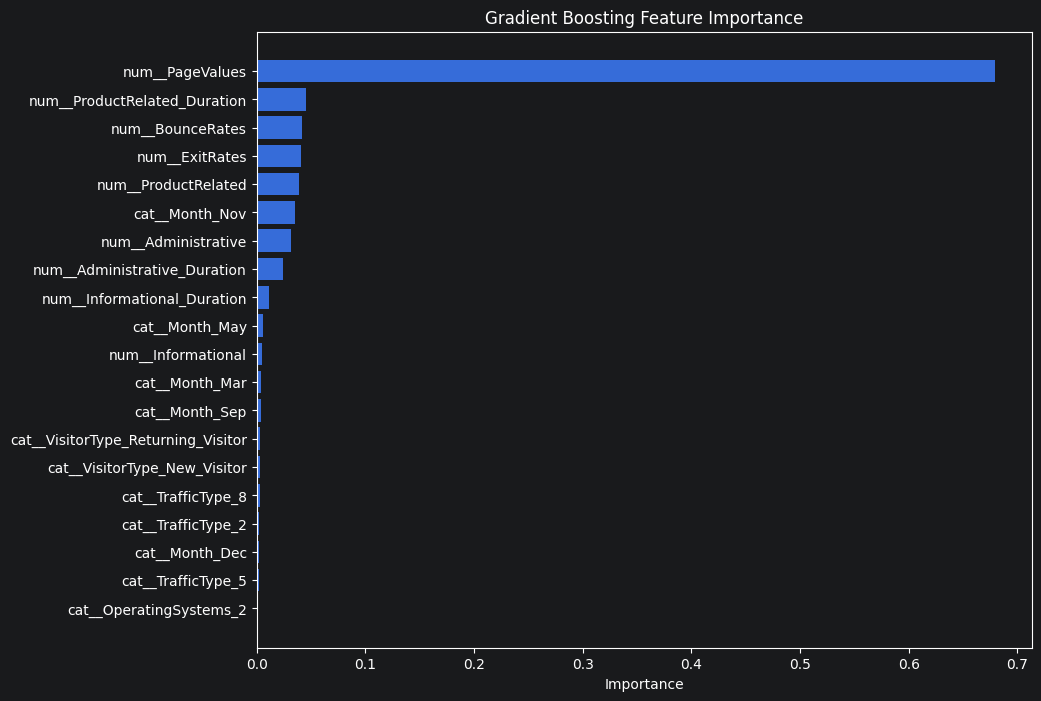

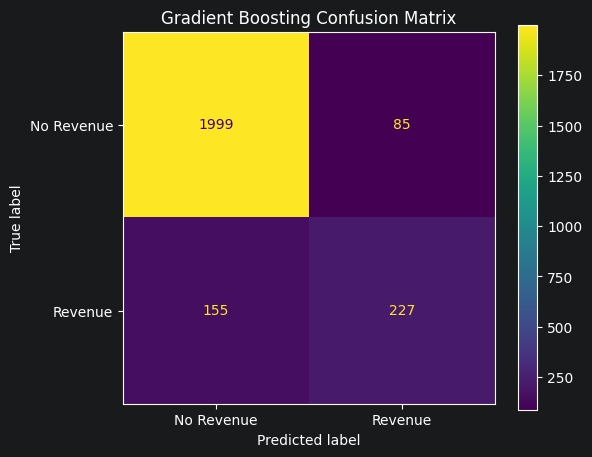

In [6]:
metrics, conf_matrix, best_params, best_model = tune_train_model(
    X_train_tree_boost,
    X_test_tree_boost,
    y_train,
    y_test,
    model_class=GradientBoostingClassifier,
    n_trials=50,
)

display(metrics)

print("Best params:")
print(best_params)

# FEATURE IMPORTANCE
feature_names = preprocessor_tree_boost.get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
)

top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()


# confusion matrix
cm = np.array([
    [conf_matrix["tn"].iloc[0], conf_matrix["fp"].iloc[0]],
    [conf_matrix["fn"].iloc[0], conf_matrix["tp"].iloc[0]],
])

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Revenue", "Revenue"]
).plot(ax=ax)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

Tune and train CatBoost

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,CatBoostClassifier,0.86618,0.544983,0.824607,0.65625,0.930063,0.740278


Best params:
{'iterations': 214, 'depth': 8, 'learning_rate': 0.03180360746598612, 'l2_leaf_reg': 11, 'random_strength': 1, 'bagging_temperature': 2.6122608012855055}


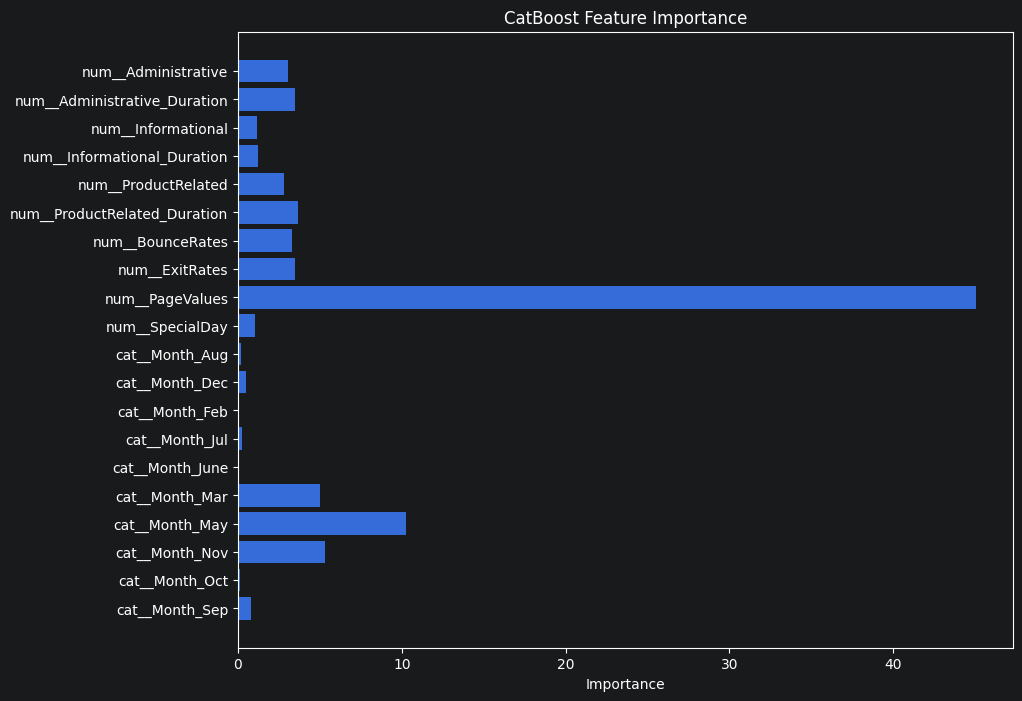

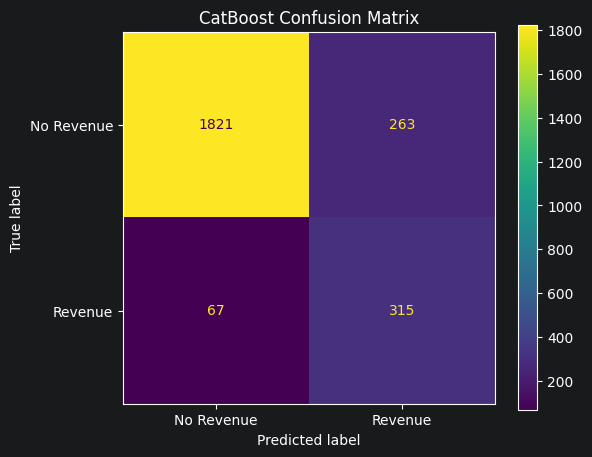

In [7]:
metrics, conf_matrix, best_params, best_model = tune_train_model(
    X_train_tree_boost,
    X_test_tree_boost,
    y_train,
    y_test,
    model_class=CatBoostClassifier,
    n_trials=50,
)

display(metrics)

print("Best params:")
print(best_params)

# FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_model.get_feature_importance()
})

top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()


# CONFUSION MATRIX
cm = np.array([
    [conf_matrix["tn"].iloc[0], conf_matrix["fp"].iloc[0]],
    [conf_matrix["fn"].iloc[0], conf_matrix["tp"].iloc[0]],
])

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Revenue", "Revenue"]
).plot(ax=ax)

plt.title("CatBoost Confusion Matrix")
plt.show()